# Inspect labeling coverage

Run all cells to view every registered class as one contact sheet. Red outlines show the upright OBB fitted to each rasterized SVG.


In [5]:
from io import BytesIO
from math import ceil
from pathlib import Path
import sys

import numpy as np
from PIL import Image, ImageDraw
from IPython.display import display

PROJECT_ROOT = next(
    root for root in (Path.cwd(), *Path.cwd().parents)
    if (root / '06_configs' / 'ontology.yaml').exists()
)
SCRIPTS_ROOT = PROJECT_ROOT / '01_scripts'
if str(SCRIPTS_ROOT) not in sys.path:
    sys.path.insert(0, str(SCRIPTS_ROOT))

from generation.core.models import GenerationConfig
from generation.core.sampling import load_sampling_config
from generation.registry import COMPOSITE_GENERATORS, GENERATOR_REGISTRY
from labeling import label_upright_png
from rasterization import rasterize_svg


## Configuration

Each class gets one deterministic sample. Adjust the canvas or grid layout here.


In [6]:
base_seed = 12345
columns = 4
tile_px = 230
alpha_threshold = 0
generation_config = GenerationConfig(
    canvas_width_px=150,
    canvas_height_px=150,
    target_visible_px=90.0,
)


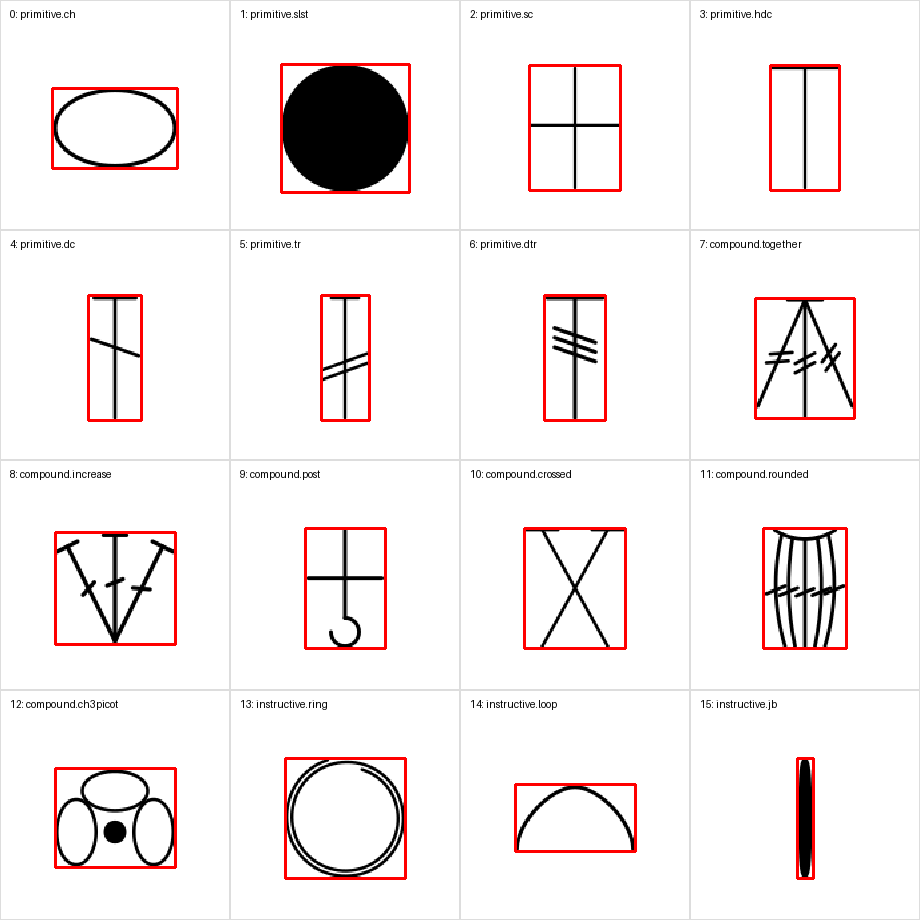

In [7]:
sampling_config = load_sampling_config(
    ontology_path=PROJECT_ROOT / '06_configs' / 'ontology.yaml',
    sampling_path=PROJECT_ROOT / '06_configs' / 'symbol_sampling.yaml',
)
class_keys = list(GENERATOR_REGISTRY)
rows = ceil(len(class_keys) / columns)
sheet = Image.new('RGB', (columns * tile_px, rows * tile_px), 'white')

for index, class_key in enumerate(class_keys):
    family, name = class_key
    rng = np.random.default_rng(base_seed + index)
    sample = sampling_config.sample(
        family, name, rng, seed=base_seed + index,
    )
    generator_input = (
        sampling_config.realize_components(family, name, sample, rng)
        if class_key in COMPOSITE_GENERATORS else sample
    )
    spec = sampling_config.resolve(family, name)
    generated = GENERATOR_REGISTRY[class_key](
        spec, generator_input, generation_config,
    )
    png_bytes = rasterize_svg(generated.svg)
    label_upright_png(generated, png_bytes, alpha_threshold=alpha_threshold)

    with Image.open(BytesIO(png_bytes)) as png:
        symbol = png.convert('RGBA')
    background = Image.new('RGBA', symbol.size, 'white')
    background.alpha_composite(symbol)

    tile = Image.new('RGB', (tile_px, tile_px), 'white')
    draw = ImageDraw.Draw(tile)
    draw.rectangle((0, 0, tile_px - 1, tile_px - 1), outline='#dddddd')
    draw.text((10, 8), f'{spec.class_id}: {family}.{name}', fill='black')

    available = tile_px - 30
    scale = min(available / symbol.width, available / symbol.height)
    size = (round(symbol.width * scale), round(symbol.height * scale))
    preview = background.convert('RGB').resize(size, Image.Resampling.NEAREST)
    origin = ((tile_px - size[0]) // 2, 26 + (tile_px - 26 - size[1]) // 2)
    tile.paste(preview, origin)
    points = [
        (origin[0] + x * size[0] / symbol.width,
         origin[1] + y * size[1] / symbol.height)
        for x, y in generated.obb_pixels
    ]
    draw.line(points + [points[0]], fill='red', width=3)

    sheet.paste(tile, ((index % columns) * tile_px, (index // columns) * tile_px))

display(sheet)
